# Matrix Multiplication in All Its Forms
### A first-principles tour for quant interviews

Matrix multiplication is *the* workhorse of quantitative finance and machine learning. Portfolio variance, factor models, linear regression, PCA, neural nets — under the hood they are all matrix products. The trouble is that most people learn matrix multiplication as a mechanical recipe ("row times column") and never build the **mental pictures** that let them reason fast under interview pressure.

This notebook fixes that. We will see the *same* operation from several angles:

1. **Inner product** — two vectors collapse into one number (similarity, projection, variance).
2. **Outer product** — two vectors expand into a whole matrix (rank-1 building blocks).
3. **Matrix × vector** — a *linear combination of columns* (the single most useful picture).
4. **Matrix × matrix** — four equivalent ways to read the same product.
5. **Data-matrix toolkit** — centering, the Gram matrix, and the covariance matrix, which are *all* just clever matrix products.
6. **Kronecker product** — how to build big structured matrices from small ones.
7. **Einstein summation** — one notation to rule them all (`np.einsum`).

> **Quant interview reality check:** Interviewers rarely ask "multiply these two matrices." They ask things like *"What's the variance of a portfolio with weights w and covariance Σ?"* or *"Why is XᵀX symmetric and positive semi-definite?"* Those are matrix-multiplication questions in disguise. Throughout, I'll flag the ideas that come up again and again with a 🎯 **Quant flag**.


## 0 · Setup and notation

Before any code, let's fix notation so nothing is ambiguous. Sloppy notation is where most matrix mistakes are born.

| Symbol | Meaning | Shape |
|---|---|---|
| $a, b$ (lower-case, bold in print) | column vectors | $n \times 1$ |
| $A, B, X$ (upper-case) | matrices | $m \times n$ |
| $a^\top$ | transpose (turns a column into a row) | $1 \times n$ |
| $a^\top b$ | **inner product** (a scalar) | $1 \times 1$ |
| $a\, b^\top$ | **outer product** (a matrix) | $n \times m$ |
| $A_{ij}$ | the entry in row $i$, column $j$ | scalar |
| $a_{:,j}$ | the $j$-th **column** of $A$ | $m \times 1$ |
| $a_{i,:}$ | the $i$-th **row** of $A$ | $1 \times n$ |

> **The golden rule of shapes:** an $(m \times n)$ matrix times an $(n \times p)$ matrix gives an $(m \times p)$ matrix. The two **inner** dimensions ($n$ and $n$) must match and they *cancel*; the two **outer** dimensions ($m$ and $p$) survive. If you remember nothing else, remember to check this before every multiply.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
rng = np.random.default_rng(0)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "#f8f8f8",
    "axes.grid":        True,
    "grid.color":       "white",
    "grid.linewidth":   1.2,
    "axes.spines.top":  False,
    "axes.spines.right": False,
    "font.family":      "sans-serif",
})

PALETTE = {
    "steelblue":     "steelblue",
    "tomato":        "tomato",
    "mediumseagreen":"mediumseagreen",
    "darkorange":    "darkorange",
    "navy":          "navy",
}
print("NumPy version:", np.__version__)

NumPy version: 2.4.6


---
## 1 · The Inner Product — two vectors become one number

**WHY first.** The inner product (a.k.a. *dot product*) answers the question: *"How much do these two vectors agree?"* It is the atom out of which every other matrix product is built. Every single entry of every matrix product you will ever compute is one inner product.

Given two vectors $a, b \in \mathbb{R}^n$:

$$
a^\top b \;=\; \sum_{i=1}^{n} a_i\, b_i \;=\; a_1 b_1 + a_2 b_2 + \dots + a_n b_n.
$$

Read it as a recipe: **multiply matching components, then add them all up.** The result is a single scalar.

**The geometric meaning** (this is the intuition interviewers love):

$$
a^\top b \;=\; \underbrace{\|a\|}_{\text{length of } a}\; \underbrace{\|b\|}_{\text{length of } b}\; \underbrace{\cos\theta}_{\text{alignment}},
$$

where $\theta$ is the angle between them. So the dot product is *"how long they are"* times *"how aligned they are."*

- $a^\top b > 0$: the vectors point in a *similar* direction (angle < 90°).
- $a^\top b = 0$: they are **orthogonal** (perpendicular) — zero agreement.
- $a^\top b < 0$: they point in *opposing* directions.

> **Key insight:** A dot product of zero means "these two carry no shared information / are uncorrelated in direction." This single fact underlies orthogonal bases, uncorrelated returns, and why $X^\top X$ being diagonal means your features are decorrelated.

🎯 **Quant flag — correlation is a normalized inner product.** If you center two return series and divide by their norms, the dot product *is* the correlation coefficient: $\rho = \frac{a^\top b}{\|a\|\,\|b\|} = \cos\theta$. Expect to be asked "what is correlation, geometrically?" — the answer is *the cosine of the angle between the (de-meaned) return vectors.*


In [2]:
def inner_product(a, b):
    """Inner product from scratch: multiply matching entries, then sum."""
    assert a.shape == b.shape, "Vectors must have the same length"
    total = 0.0
    for ai, bi in zip(a, b):
        total += ai * bi
    return total

a = np.array([2.0, 1.0, 3.0])
b = np.array([1.0, 4.0, 0.0])

print("from scratch :", inner_product(a, b))
print("np.dot       :", np.dot(a, b))
print("a @ b        :", a @ b)            # '@' is the matmul operator (cleanest syntax)
print("a.T @ b      :", a.T @ b)          # for 1-D arrays transpose does nothing, same result

# Geometric check: recover the angle between the vectors
cos_theta = (a @ b) / (np.linalg.norm(a) * np.linalg.norm(b))
print(f"\ncos(theta) = {cos_theta:.3f}  ->  angle = {np.degrees(np.arccos(cos_theta)):.1f} degrees")

from scratch : 6.0
np.dot       : 6.0
a @ b        : 6.0
a.T @ b      : 6.0

cos(theta) = 0.389  ->  angle = 67.1 degrees


### Visualizing the inner product as a projection

The cleanest picture: the dot product measures the **shadow** that $b$ casts onto the direction of $a$ (scaled by the length of $a$). When $b$ is perpendicular to $a$, the shadow has zero length, so the dot product is zero.


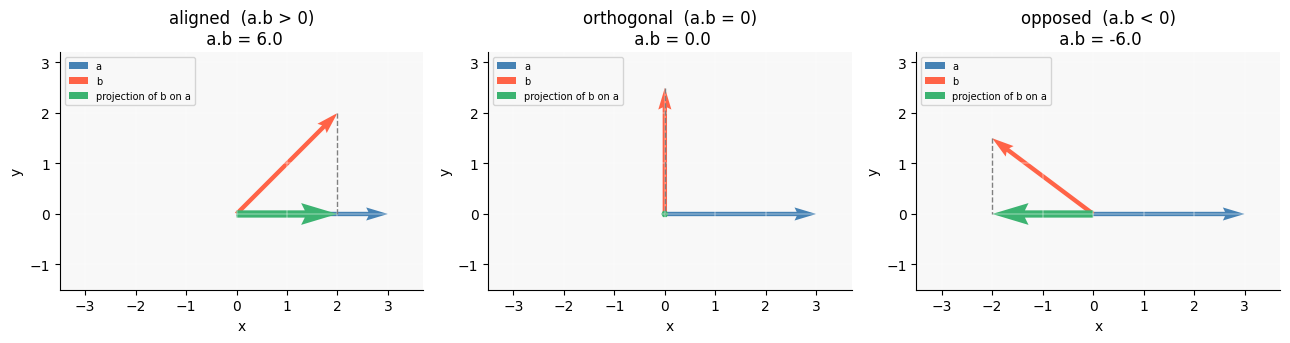

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
pairs = [
    (np.array([3, 0]), np.array([2, 2]),  "aligned  (a.b > 0)"),
    (np.array([3, 0]), np.array([0, 2.5]),"orthogonal  (a.b = 0)"),
    (np.array([3, 0]), np.array([-2, 1.5]),"opposed  (a.b < 0)"),
]
for ax, (av, bv, title) in zip(axes, pairs):
    # projection of b onto a:  (a.b / a.a) * a
    proj = (av @ bv) / (av @ av) * av
    ax.quiver(0, 0, *av, angles="xy", scale_units="xy", scale=1,
              color=PALETTE["steelblue"], width=0.012, label="a")
    ax.quiver(0, 0, *bv, angles="xy", scale_units="xy", scale=1,
              color=PALETTE["tomato"], width=0.012, label="b")
    ax.quiver(0, 0, *proj, angles="xy", scale_units="xy", scale=1,
              color=PALETTE["mediumseagreen"], width=0.02, label="projection of b on a")
    # dashed line from b down to its shadow
    ax.plot([bv[0], proj[0]], [bv[1], proj[1]], "--", color="gray", lw=1)
    ax.set_xlim(-3.5, 3.7); ax.set_ylim(-1.5, 3.2)
    ax.set_aspect("equal")
    ax.set_title(f"{title}\n a.b = {av @ bv:.1f}")
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7, loc="upper left")
plt.tight_layout()
plt.show()

---
## 2 · The Outer Product — two vectors become a whole matrix

**WHY.** The outer product is the inner product's mirror image. Instead of *collapsing* two vectors into a scalar, it *expands* them into a full matrix. It is how you build matrices out of vectors, and it is the secret ingredient behind low-rank approximations, SVD, and PCA.

Given $a \in \mathbb{R}^m$ and $b \in \mathbb{R}^n$, the outer product is the $m \times n$ matrix:

$$
a\,b^\top \;=\;
\begin{bmatrix} a_1 \\ a_2 \\ \vdots \\ a_m \end{bmatrix}
\begin{bmatrix} b_1 & b_2 & \cdots & b_n \end{bmatrix}
\;=\;
\begin{bmatrix}
a_1 b_1 & a_1 b_2 & \cdots & a_1 b_n \\
a_2 b_1 & a_2 b_2 & \cdots & a_2 b_n \\
\vdots  & \vdots  & \ddots & \vdots  \\
a_m b_1 & a_m b_2 & \cdots & a_m b_n
\end{bmatrix}.
$$

Entry $(i,j)$ is simply $a_i b_j$ — *"every component of $a$ multiplied by every component of $b$."* It's a multiplication table.

> **Key insight:** Every outer product is a **rank-1 matrix**. Every column is a rescaled copy of $a$; every row is a rescaled copy of $b$. There is really only one independent direction in there. This is profound: the SVD says *any* matrix is a sum of rank-1 outer products $\sum_k \sigma_k u_k v_k^\top$, ordered from most to least important. Truncating that sum is exactly how PCA / low-rank compression works.

🎯 **Quant flag.** "What is a rank-1 matrix?" and "What does the outer product $uv^\top$ look like?" are common warm-up questions. Also: a covariance matrix from a *single* observation is the outer product of the (centered) observation with itself — and the full covariance is the **average of such outer products**. Keep that link in your back pocket.


In [4]:
def outer_product(a, b):
    """Outer product from scratch: entry (i, j) = a_i * b_j."""
    M = np.zeros((len(a), len(b)))
    for i in range(len(a)):
        for j in range(len(b)):
            M[i, j] = a[i] * b[j]
    return M

a = np.array([1.0, 2.0, 3.0])
b = np.array([10.0, 20.0])

print("from scratch:\n", outer_product(a, b))
print("\nnp.outer:\n", np.outer(a, b))

# rank is 1, always
print("\nrank of outer product:", np.linalg.matrix_rank(np.outer(a, b)))

from scratch:
 [[10. 20.]
 [20. 40.]
 [30. 60.]]

np.outer:
 [[10. 20.]
 [20. 40.]
 [30. 60.]]

rank of outer product: 1


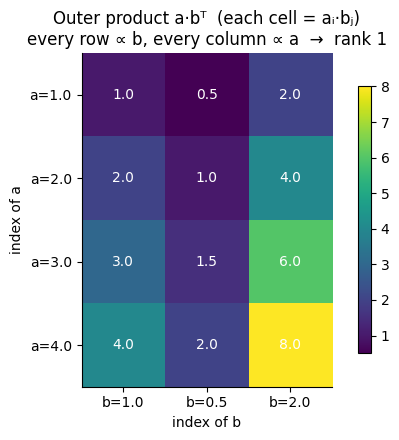

In [5]:
# Visual: outer product is a 'multiplication table' heatmap, and it is rank-1
a = np.array([1.0, 2.0, 3.0, 4.0])
b = np.array([1.0, 0.5, 2.0])
M = np.outer(a, b)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(M, cmap="viridis")
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        ax.text(j, i, f"{M[i,j]:.1f}", ha="center", va="center", color="white")
ax.set_xticks(range(len(b))); ax.set_xticklabels([f"b={v}" for v in b])
ax.set_yticks(range(len(a))); ax.set_yticklabels([f"a={v}" for v in a])
ax.set_title("Outer product a·bᵀ  (each cell = aᵢ·bⱼ)\nevery row ∝ b, every column ∝ a  →  rank 1")
ax.set_xlabel("index of b"); ax.set_ylabel("index of a")
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

### Inner vs outer at a glance

Same two vectors, two opposite operations. The *order* and the *transpose* decide which one you get.

| | Inner product $a^\top b$ | Outer product $a\,b^\top$ |
|---|---|---|
| Shapes | $(1\times n)(n\times 1)$ | $(m\times 1)(1\times n)$ |
| Result | scalar $1\times1$ | matrix $m\times n$ |
| Question it answers | "how aligned?" | "all pairwise products" |
| Rank of result | — | always 1 |
| Shows up in | similarity, variance, projection | covariance, SVD, PCA |

> **Memory hook:** the **inner** dimensions touch in the inner product (the $n$'s cancel → scalar). In the outer product the **outer** dimensions are exposed (the $1$'s touch → a big $m\times n$ matrix blooms out).


---
## 3 · Matrix × Vector — a linear combination of columns

**WHY this is the most important picture in all of linear algebra.** Almost everyone learns $Ax$ as "dot each row of $A$ with $x$." That's correct but it hides the meaning. The deeper, more useful view is:

$$
A x \;=\; x_1\, a_{:,1} + x_2\, a_{:,2} + \dots + x_n\, a_{:,n}.
$$

In words: **$Ax$ is a weighted sum (linear combination) of the columns of $A$, where the weights are the entries of $x$.** The vector $x$ is a *recipe* telling you how much of each column to mix.

Let's see both views explicitly for a $2\times 3$ example. With
$A = \begin{bmatrix} a_{11} & a_{12} & a_{13} \\ a_{21} & a_{22} & a_{23}\end{bmatrix}$ and $x = \begin{bmatrix}x_1\\x_2\\x_3\end{bmatrix}$:

$$
\textbf{Row view: } Ax = \begin{bmatrix} a_{1,:}^\top x \\ a_{2,:}^\top x \end{bmatrix}
\qquad\qquad
\textbf{Column view: } Ax = x_1\!\begin{bmatrix}a_{11}\\a_{21}\end{bmatrix} + x_2\!\begin{bmatrix}a_{12}\\a_{22}\end{bmatrix} + x_3\!\begin{bmatrix}a_{13}\\a_{23}\end{bmatrix}
$$

Both give the same answer. The row view is good for *computing*; the column view is good for *understanding*.

> **Key insight:** The set of *all* vectors you can reach by choosing different $x$ is exactly the **column space** of $A$ — everything you can build by mixing its columns. "Can I solve $Ax=b$?" becomes "Is $b$ a mixture of $A$'s columns?" This reframing makes rank, span, and solvability click.

🎯 **Quant flag — this *is* a linear factor model.** When you write asset returns as $r = B f + \varepsilon$, the matrix-vector product $Bf$ is literally "a linear combination of factor-loading columns weighted by factor returns." A portfolio's exposure, the payoff of a basket, the value of a bond as a weighted sum of cash flows — all are matrix-vector products read in the column view.


In [6]:
A = np.array([[2.0, 0.0, 1.0],
              [1.0, 3.0, 1.0]])
x = np.array([1.0, 2.0, -1.0])

# View 1: rows dotted with x
row_view = np.array([A[i, :] @ x for i in range(A.shape[0])])

# View 2: weighted sum of columns
col_view = sum(x[j] * A[:, j] for j in range(A.shape[1]))

print("row view (dot each row): ", row_view)
print("column view (mix cols):  ", col_view)
print("numpy A @ x:             ", A @ x)
print("\nAll three agree:", np.allclose(row_view, col_view) and np.allclose(col_view, A @ x))

row view (dot each row):  [1. 6.]
column view (mix cols):   [1. 6.]
numpy A @ x:              [1. 6.]

All three agree: True


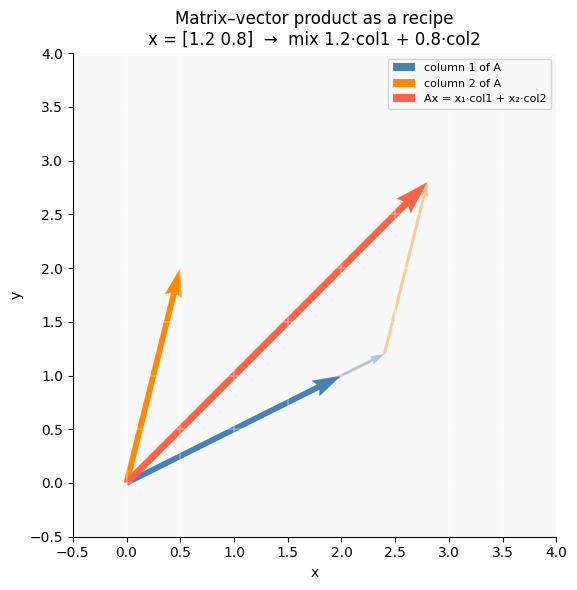

In [7]:
# Visualize the column view: Ax lands inside the span of A's columns
A = np.array([[2.0, 0.5],
              [1.0, 2.0]])
x = np.array([1.2, 0.8])
c1, c2 = A[:, 0], A[:, 1]
result = A @ x

fig, ax = plt.subplots(figsize=(6, 6))
# the two columns of A
ax.quiver(0, 0, *c1, angles="xy", scale_units="xy", scale=1, color=PALETTE["steelblue"], width=0.012, label="column 1 of A")
ax.quiver(0, 0, *c2, angles="xy", scale_units="xy", scale=1, color=PALETTE["darkorange"], width=0.012, label="column 2 of A")
# scaled copies (the recipe)
ax.quiver(0, 0, *(x[0]*c1), angles="xy", scale_units="xy", scale=1, color=PALETTE["steelblue"], width=0.006, alpha=0.4)
ax.quiver(*(x[0]*c1), *(x[1]*c2), angles="xy", scale_units="xy", scale=1, color=PALETTE["darkorange"], width=0.006, alpha=0.4)
# the result
ax.quiver(0, 0, *result, angles="xy", scale_units="xy", scale=1, color=PALETTE["tomato"], width=0.014, label="Ax = x₁·col1 + x₂·col2")
ax.set_xlim(-0.5, 4); ax.set_ylim(-0.5, 4)
ax.set_aspect("equal")
ax.set_title(f"Matrix–vector product as a recipe\nx = {x}  →  mix {x[0]}·col1 + {x[1]}·col2")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

---
## 4 · Matrix × Matrix — four ways to read one product

**WHY.** $C = AB$ is the operation everything reduces to, and it has (at least) four equivalent interpretations. Knowing all four lets you pick the easiest one for any given problem — a genuine interview superpower.

Let $A$ be $m\times k$ and $B$ be $k\times n$, so $C = AB$ is $m\times n$.

**View 1 — Entry by entry (the textbook recipe).** Each entry is an inner product of a row of $A$ with a column of $B$:
$$ C_{ij} = \sum_{\ell=1}^{k} A_{i\ell}\, B_{\ell j} = a_{i,:}^\top\, b_{:,j}. $$
*"Row $i$ meets column $j$."*

**View 2 — Column by column.** Each column of $C$ is $A$ times the matching column of $B$ (so it's a linear combination of $A$'s columns, from Section 3):
$$ c_{:,j} = A\, b_{:,j}. $$
*"$B$'s columns are recipes; $C$'s columns are the resulting mixtures of $A$'s columns."*

**View 3 — Row by row.** Each row of $C$ is the matching row of $A$ times $B$:
$$ c_{i,:} = a_{i,:}\, B. $$

**View 4 — Sum of outer products (the one people forget!).** $C$ is the sum over the shared dimension of outer products of $A$'s columns with $B$'s rows:
$$ C = \sum_{\ell=1}^{k} a_{:,\ell}\, b_{\ell,:}. $$
*"Stack $k$ rank-1 layers on top of each other."* This is the bridge to SVD and is the cleanest way to see why $\text{rank}(AB) \le \min(\text{rank}\,A, \text{rank}\,B)$.

> **Key insight:** Matrix multiplication is **not commutative** ($AB \ne BA$ in general — they may not even have compatible shapes), but it **is** associative ($A(BC) = (AB)C$). Associativity is worth real money: choosing the order of multiplication can change the FLOP count by orders of magnitude (the matrix-chain problem).

🎯 **Quant flag.** (1) Be ready to prove $(AB)^\top = B^\top A^\top$ — *transpose reverses order*. (2) Know that $AB \ne BA$ and be able to give a 2×2 counterexample on the spot. (3) The associativity/efficiency point — e.g. computing $w^\top(\Sigma w)$ as a matrix-vector then a dot product, not $(w^\top\Sigma)w$ as forming a row first — is a favorite "how would you make this fast?" follow-up.


In [8]:
def matmul_from_scratch(A, B):
    """Triple-loop matrix multiply (View 1) — for understanding, not speed."""
    m, k = A.shape
    k2, n = B.shape
    assert k == k2, f"inner dims must match: {k} vs {k2}"
    C = np.zeros((m, n))
    for i in range(m):
        for j in range(n):
            for l in range(k):
                C[i, j] += A[i, l] * B[l, j]
    return C

A = rng.integers(-3, 4, size=(3, 2)).astype(float)
B = rng.integers(-3, 4, size=(2, 4)).astype(float)

C_scratch = matmul_from_scratch(A, B)
C_numpy   = A @ B

# View 4: sum of outer products of A's columns with B's rows
C_outer = sum(np.outer(A[:, l], B[l, :]) for l in range(A.shape[1]))

print("triple loop  == numpy:", np.allclose(C_scratch, C_numpy))
print("outer sum    == numpy:", np.allclose(C_outer, C_numpy))
print("\nC = A @ B:\n", C_numpy)

triple loop  == numpy: True
outer sum    == numpy: True

C = A @ B:
 [[-5. -3. -4.  5.]
 [-2. -6.  0. -2.]
 [ 0. -6.  2. -5.]]


In [9]:
# Demonstrate the three interview facts numerically
A = rng.standard_normal((3, 3))
B = rng.standard_normal((3, 3))
C = rng.standard_normal((3, 3))

print("1) Non-commutative:   AB == BA ?", np.allclose(A @ B, B @ A))
print("2) Associative:       A(BC) == (AB)C ?", np.allclose(A @ (B @ C), (A @ B) @ C))
print("3) Transpose reverses: (AB)ᵀ == BᵀAᵀ ?", np.allclose((A @ B).T, B.T @ A.T))

# Why order matters for speed: chain of (1x1000)(1000x1000)(1000x1) 
import time
u = rng.standard_normal((1, 1000)); M = rng.standard_normal((1000, 1000)); v = rng.standard_normal((1000, 1))
t0 = time.perf_counter(); _ = (u @ M) @ v; t_good = time.perf_counter() - t0   # cheap: (1x1000)(1000x1000)->(1x1000), then dot
t0 = time.perf_counter(); _ = u @ (M @ v); t_alt  = time.perf_counter() - t0   # also cheap here, both fine
print(f"\nSame result, both orders fast for this shape. The lesson: count FLOPs before choosing an order.")

1) Non-commutative:   AB == BA ? False
2) Associative:       A(BC) == (AB)C ? True
3) Transpose reverses: (AB)ᵀ == BᵀAᵀ ? True

Same result, both orders fast for this shape. The lesson: count FLOPs before choosing an order.


---
## 5 · The Data-Matrix Toolkit — centering, Gram, and covariance

**WHY.** This is where matrix multiplication earns its keep in quant work. We now have a **data matrix** $X$ of shape $n \times d$: $n$ observations (rows) of $d$ features (columns) — think $n$ trading days of $d$ asset returns. Three operations come up constantly, and *all three are matrix products in disguise.*

### 5a · Centering — subtract the mean from each column

The column means are $\bar{x} = \frac{1}{n}\mathbf{1}^\top X$ (a row vector; $\mathbf{1}$ is the all-ones column). Centering subtracts that mean from every row:

$$
X_c \;=\; X - \mathbf{1}\,\bar{x} \;=\; \Big(I - \tfrac{1}{n}\mathbf{1}\mathbf{1}^\top\Big) X \;=\; H X.
$$

The matrix $H = I - \frac{1}{n}\mathbf{1}\mathbf{1}^\top$ is the **centering matrix**. Notice $\frac{1}{n}\mathbf{1}\mathbf{1}^\top$ is exactly the outer product from Section 2! Multiplying by $H$ "removes the average direction."

### 5b · The Gram matrix $X^\top X$ — all pairwise inner products of features

$$
G = X^\top X, \qquad G_{ij} = x_{:,i}^\top x_{:,j} = (\text{column } i)\cdot(\text{column } j).
$$

Entry $(i,j)$ is the inner product of feature $i$ with feature $j$ — a table of "how much each feature agrees with each other feature." From Section 4 View 4, $G = \sum_{\text{rows}} x_r x_r^\top$, a sum of outer products of the observations.

> **Key insight:** $X^\top X$ is always **symmetric** (because $(X^\top X)^\top = X^\top X$) and **positive semi-definite** (because $z^\top X^\top X z = \|Xz\|^2 \ge 0$ — it's a squared length, which can't be negative). These two properties are why it appears everywhere: least squares, kernels, covariance.

### 5c · The covariance matrix — a scaled Gram matrix of centered data

$$
\Sigma \;=\; \frac{1}{n-1} X_c^\top X_c \;=\; \frac{1}{n-1}(HX)^\top (HX).
$$

So covariance = **center, then Gram, then divide by $n-1$.** The diagonal holds variances; the off-diagonals hold covariances. (We use $n-1$, *Bessel's correction*, for an unbiased estimate.)

🎯 **Quant flag — this section is interview gold.**
- *"Why is the covariance matrix symmetric and PSD?"* → because it's $\frac{1}{n-1}X_c^\top X_c$ (see the boxed insight). A *true* covariance matrix can never have a negative eigenvalue.
- *"What is portfolio variance?"* → $\sigma_p^2 = w^\top \Sigma\, w$. This is a quadratic form: an inner product of $w$ with $\Sigma w$. **Memorize this.** It must be $\ge 0$, which is *exactly* the PSD property.
- *"How do you get correlation from covariance?"* → $\text{Corr} = D^{-1/2}\,\Sigma\, D^{-1/2}$ where $D$ is the diagonal of variances.


In [10]:
# Synthetic 'returns' data matrix: n days x d assets, with built-in correlation
n, d = 500, 3
true_cov = np.array([[1.0,  0.6, -0.2],
                     [0.6,  1.0,  0.1],
                     [-0.2, 0.1,  1.5]])
L = np.linalg.cholesky(true_cov)
X = (rng.standard_normal((n, d)) @ L.T) + np.array([0.05, -0.02, 0.10])  # add nonzero means
print("Data matrix X shape:", X.shape, " (n days x d assets)")

# --- 5a: centering via the centering matrix H = I - (1/n) 11ᵀ ---
ones = np.ones((n, 1))
H = np.eye(n) - (ones @ ones.T) / n          # outer product 11ᵀ inside!
Xc_matrix = H @ X
Xc_direct = X - X.mean(axis=0)               # the everyday way
print("\nCentering via H matches X - mean:", np.allclose(Xc_matrix, Xc_direct))
print("Column means after centering (≈0):", Xc_matrix.mean(axis=0))

# --- 5b: Gram matrix of features ---
G = X.T @ X
print("\nGram matrix XᵀX (3x3):\n", G)
print("Symmetric?", np.allclose(G, G.T))
print("All eigenvalues >= 0 (PSD)?", np.all(np.linalg.eigvalsh(G) >= -1e-9))

# --- 5c: covariance = centered Gram / (n-1) ---
Sigma = (Xc_matrix.T @ Xc_matrix) / (n - 1)
print("\nOur covariance:\n", Sigma)
print("\nnp.cov matches?", np.allclose(Sigma, np.cov(X, rowvar=False)))

Data matrix X shape: (500, 3)  (n days x d assets)

Centering via H matches X - mean: True
Column means after centering (≈0): [-0.  0. -0.]

Gram matrix XᵀX (3x3):
 [[ 494.835  312.482 -107.124]
 [ 312.482  502.398   41.623]
 [-107.124   41.623  778.144]]
Symmetric? True
All eigenvalues >= 0 (PSD)? True

Our covariance:
 [[ 0.99   0.628 -0.217]
 [ 0.628  1.003  0.087]
 [-0.217  0.087  1.556]]

np.cov matches? True


In [11]:
# Portfolio variance as a quadratic form  w'Σw  — and a sanity check by simulation
w = np.array([0.5, 0.3, 0.2])                       # portfolio weights, sum to 1
port_var_formula = w @ Sigma @ w                    # the quadratic form
port_returns = Xc_matrix @ w                         # daily portfolio (centered) returns
port_var_empirical = port_returns.var(ddof=1)

print(f"Portfolio variance via  wᵀΣw      : {port_var_formula:.4f}")
print(f"Portfolio variance via simulation : {port_var_empirical:.4f}")
print(f"Portfolio volatility (std)        : {np.sqrt(port_var_formula):.4f}")
print("\n-> w'Σw IS the variance of the linear combination Xc @ w. This is the key quant identity.")

Portfolio variance via  wᵀΣw      : 0.5557
Portfolio variance via simulation : 0.5557
Portfolio volatility (std)        : 0.7454

-> w'Σw IS the variance of the linear combination Xc @ w. This is the key quant identity.


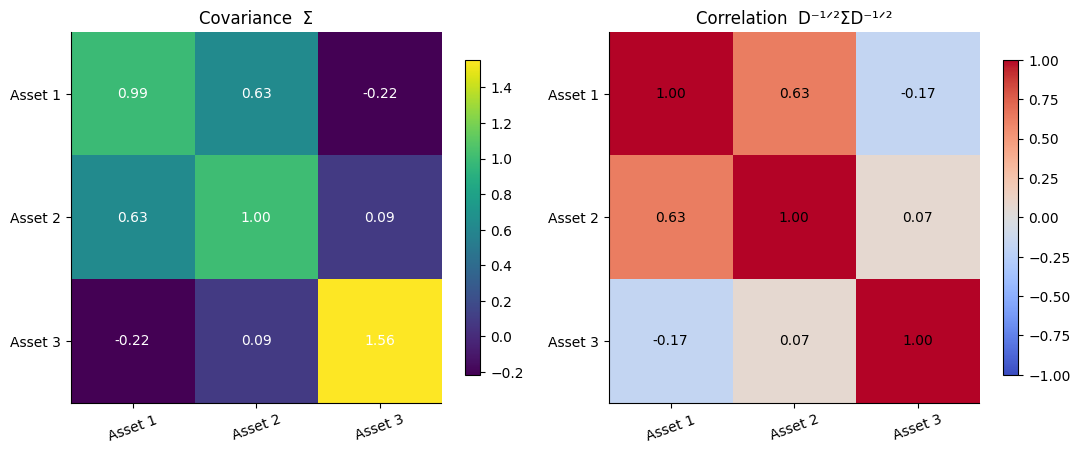

In [12]:
# Visualize covariance and the derived correlation matrix as heatmaps
D_inv_sqrt = np.diag(1.0 / np.sqrt(np.diag(Sigma)))
Corr = D_inv_sqrt @ Sigma @ D_inv_sqrt              # standardize: D^-1/2 Σ D^-1/2
labels = ["Asset 1", "Asset 2", "Asset 3"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, M, name, cmap in [(axes[0], Sigma, "Covariance  Σ", "viridis"),
                          (axes[1], Corr, "Correlation  D⁻¹ᐟ²ΣD⁻¹ᐟ²", "coolwarm")]:
    im = ax.imshow(M, cmap=cmap, vmin=-1 if name.startswith("Corr") else None,
                   vmax=1 if name.startswith("Corr") else None)
    for i in range(d):
        for j in range(d):
            ax.text(j, i, f"{M[i,j]:.2f}", ha="center", va="center",
                    color="white" if name.startswith("Cov") else "black")
    ax.set_xticks(range(d)); ax.set_xticklabels(labels, rotation=20)
    ax.set_yticks(range(d)); ax.set_yticklabels(labels)
    ax.set_title(name)
    ax.grid(False)
    fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

---
## 6 · The Kronecker Product — building big structured matrices from small ones

**WHY.** Sometimes you need a large matrix that has a repeating block structure — covariance of returns across *both* assets *and* time, vectorized linear systems, tensor / lattice models. The **Kronecker product** $\otimes$ builds such matrices cheaply by "stamping" one matrix scaled by each entry of another.

For $A$ of shape $m\times n$ and $B$ of shape $p\times q$, $A \otimes B$ has shape $(mp)\times(nq)$:

$$
A \otimes B \;=\;
\begin{bmatrix}
A_{11} B & A_{12} B & \cdots & A_{1n} B \\
A_{21} B & A_{22} B & \cdots & A_{2n} B \\
\vdots   & \vdots   & \ddots & \vdots   \\
A_{m1} B & A_{m2} B & \cdots & A_{mn} B
\end{bmatrix}.
$$

Read it as: *"take the layout of $A$, and replace each number $A_{ij}$ by a whole copy of $B$ scaled by that number."* It's a fractal-like blow-up. (Compare with the outer product, which replaces each $a_i$ by a scaled scalar $b_j$ — the Kronecker product is the *block* generalization.)

> **Key insight — the vectorization trick:** the identity $\;\text{vec}(AXB) = (B^\top \otimes A)\,\text{vec}(X)\;$ turns a matrix equation into an ordinary $Mx=b$ system. This is how solvers handle Sylvester/Lyapunov equations (which show up in continuous-time portfolio and control problems).

Handy properties (interviewers occasionally probe these):
- $(A\otimes B)(C\otimes D) = (AC)\otimes(BD)$ — the *mixed-product property*.
- $(A\otimes B)^{-1} = A^{-1}\otimes B^{-1}$, and $(A\otimes B)^\top = A^\top\otimes B^\top$.
- eigenvalues of $A\otimes B$ are all products $\lambda_i(A)\,\mu_j(B)$.

🎯 **Quant flag.** Kronecker products are how you express the covariance of a *matrix* of data (assets × time) when you assume **separable** structure $\Sigma = \Sigma_{\text{asset}} \otimes \Sigma_{\text{time}}$. Knowing the eigenvalue rule lets you reason about such a system without ever forming the giant matrix.


In [13]:
def kron_from_scratch(A, B):
    """Kronecker product: stamp a copy of B scaled by each entry of A."""
    m, n = A.shape
    p, q = B.shape
    K = np.zeros((m * p, n * q))
    for i in range(m):
        for j in range(n):
            K[i*p:(i+1)*p, j*q:(j+1)*q] = A[i, j] * B
    return K

A = np.array([[1.0, 2.0],
              [0.0, 3.0]])
B = np.array([[1.0, 1.0],
              [0.0, 1.0]])

print("from scratch:\n", kron_from_scratch(A, B))
print("\nnp.kron:\n", np.kron(A, B))
print("\nshape: (2·2) x (2·2) =", np.kron(A, B).shape)

# Eigenvalue rule check
eigA = np.linalg.eigvals(A); eigB = np.linalg.eigvals(B)
print("\neig(A)⊗eig(B) products :", np.sort(np.outer(eigA, eigB).ravel()))
print("eig(A⊗B)               :", np.sort(np.linalg.eigvals(np.kron(A, B))))

from scratch:
 [[1. 1. 2. 2.]
 [0. 1. 0. 2.]
 [0. 0. 3. 3.]
 [0. 0. 0. 3.]]

np.kron:
 [[1. 1. 2. 2.]
 [0. 1. 0. 2.]
 [0. 0. 3. 3.]
 [0. 0. 0. 3.]]

shape: (2·2) x (2·2) = (4, 4)

eig(A)⊗eig(B) products : [1. 1. 3. 3.]
eig(A⊗B)               : [1. 1. 3. 3.]


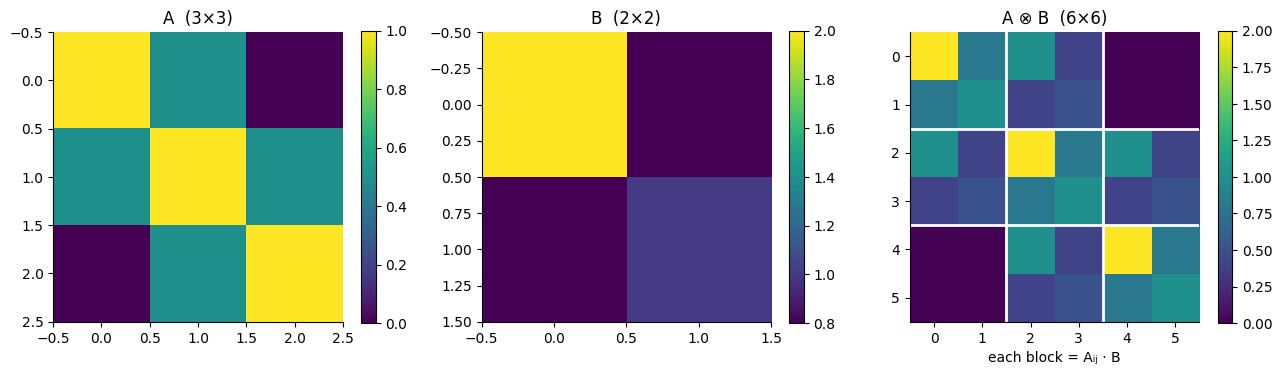

In [14]:
# Visualize the block 'stamping' structure
A = np.array([[1.0, 0.5, 0.0],
              [0.5, 1.0, 0.5],
              [0.0, 0.5, 1.0]])          # a small 'time' covariance (tridiagonal-ish)
B = np.array([[2.0, 0.8],
              [0.8, 1.0]])               # a small 'asset' covariance
K = np.kron(A, B)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, M, name in [(axes[0], A, "A  (3×3)"), (axes[1], B, "B  (2×2)"), (axes[2], K, "A ⊗ B  (6×6)")]:
    im = ax.imshow(M, cmap="viridis")
    ax.set_title(name); ax.grid(False)
    fig.colorbar(im, ax=ax, shrink=0.75)
# draw block boundaries on the Kronecker result
for k in range(1, 3):
    axes[2].axhline(k*2 - 0.5, color="white", lw=2)
    axes[2].axvline(k*2 - 0.5, color="white", lw=2)
axes[2].set_xlabel("each block = Aᵢⱼ · B")
plt.tight_layout()
plt.show()

---
## 7 · Einstein Summation — one notation for all of the above

**WHY.** Once you have inner, outer, matrix-vector, matrix-matrix, batched, and trace operations, juggling transposes and `reshape`s gets error-prone. **Einstein summation** (`np.einsum`) is a tiny, explicit language that expresses *all* of them with one rule. Quants and ML engineers use it constantly because it is unambiguous and often faster (it can skip building intermediates).

**The one rule:** write the indices of each input, then the indices of the output. *Any index that appears in the inputs but not the output is summed over.* Repeated indices that line up get multiplied.

$$
\underbrace{C_{ij} = \sum_\ell A_{i\ell} B_{\ell j}}_{\text{math}}
\quad\Longleftrightarrow\quad
\underbrace{\texttt{np.einsum('il,lj->ij', A, B)}}_{\text{code}}
$$

The shared index `l` appears on both inputs but **not** in the output `ij`, so it is the one being summed — exactly the contraction dimension. Here is the whole zoo in one table:

| Operation | Math | `einsum` string |
|---|---|---|
| Inner product | $\sum_i a_i b_i$ | `'i,i->'` |
| Outer product | $a_i b_j$ | `'i,j->ij'` |
| Matrix–vector | $\sum_j A_{ij}x_j$ | `'ij,j->i'` |
| Matrix–matrix | $\sum_\ell A_{i\ell}B_{\ell j}$ | `'il,lj->ij'` |
| Transpose | $A_{ji}$ | `'ij->ji'` |
| Trace | $\sum_i A_{ii}$ | `'ii->'` |
| Row sums | $\sum_j A_{ij}$ | `'ij->i'` |
| Quadratic form $w^\top\Sigma w$ | $\sum_{ij} w_i\Sigma_{ij}w_j$ | `'i,ij,j->'` |
| Batched matmul | $\sum_\ell A_{bi\ell}B_{b\ell j}$ | `'bil,blj->bij'` |

> **Key insight:** `einsum` makes the *summation index explicit*, which is precisely the thing that's hidden in `@`. If you can write an operation in index notation, you can write it in one `einsum` call — no transposes, no guessing about which axis numpy will broadcast.

🎯 **Quant flag.** Being fluent in index notation lets you answer "what does this tensor operation compute?" instantly, and it's the lingua franca for describing factor models and risk attributions compactly. The quadratic-form one-liner `'i,ij,j->'` for portfolio variance is a particularly slick thing to know.


In [15]:
a = rng.standard_normal(4)
b = rng.standard_normal(4)
A = rng.standard_normal((3, 4))
B = rng.standard_normal((4, 5))
x = rng.standard_normal(4)
w = rng.standard_normal(3)
S = rng.standard_normal((3, 3)); S = S @ S.T   # make a symmetric PSD matrix

checks = [
    ("inner  a·b",          np.einsum('i,i->', a, b),        a @ b),
    ("outer  a bᵀ",         np.einsum('i,j->ij', a, b),      np.outer(a, b)),
    ("mat-vec A x",         np.einsum('ij,j->i', A, x),      A @ x),
    ("mat-mat A B",         np.einsum('il,lj->ij', A, B),    A @ B),
    ("transpose Aᵀ",        np.einsum('ij->ji', A),          A.T),
    ("trace tr(S)",         np.einsum('ii->', S),            np.trace(S)),
    ("quad form wᵀSw",      np.einsum('i,ij,j->', w, S, w),  w @ S @ w),
]
for name, got, ref in checks:
    print(f"{name:18s} einsum matches reference: {np.allclose(got, ref)}")

# Batched matmul: 10 separate (2x3)(3x4) products at once — no Python loop
Ab = rng.standard_normal((10, 2, 3))
Bb = rng.standard_normal((10, 3, 4))
batched = np.einsum('bil,blj->bij', Ab, Bb)
loop    = np.stack([Ab[k] @ Bb[k] for k in range(10)])
print("\nbatched matmul matches Python loop:", np.allclose(batched, loop), " shape:", batched.shape)

inner  a·b         einsum matches reference: True
outer  a bᵀ        einsum matches reference: True
mat-vec A x        einsum matches reference: True
mat-mat A B        einsum matches reference: True
transpose Aᵀ       einsum matches reference: True
trace tr(S)        einsum matches reference: True
quad form wᵀSw     einsum matches reference: True

batched matmul matches Python loop: True  shape: (10, 2, 4)


---
## 8 · Interactive — feel matrix × vector as a linear map

A $2\times 2$ matrix is a transformation of the plane: it takes the unit square (and the circle of all unit vectors) and stretches, rotates, and shears it. Drag the sliders for the four entries of $A$ and watch how the columns of $A$ become the images of the basis vectors $\hat e_1, \hat e_2$ — the cleanest demonstration of the "columns are where the basis lands" idea from Section 3.

> If `ipywidgets` isn't installed, the static fallback below still renders one example.


In [16]:
def show_linear_map(a11=1.0, a12=0.5, a21=0.0, a22=1.0):
    A = np.array([[a11, a12], [a21, a22]])
    # unit circle and unit square
    t = np.linspace(0, 2*np.pi, 200)
    circle = np.vstack([np.cos(t), np.sin(t)])
    square = np.array([[0,1,1,0,0],[0,0,1,1,0]])
    Ac, Asq = A @ circle, A @ square

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot(*circle, color="gray", ls="--", lw=1, label="unit circle (before)")
    ax.plot(*square, color="gray", lw=1)
    ax.plot(*Ac, color=PALETTE["steelblue"], lw=2, label="A·(circle) (after)")
    ax.plot(*Asq, color=PALETTE["mediumseagreen"], lw=1.5)
    ax.quiver(0,0,*A[:,0], angles="xy", scale_units="xy", scale=1, color=PALETTE["tomato"], width=0.012, label="A·ê₁ = col 1")
    ax.quiver(0,0,*A[:,1], angles="xy", scale_units="xy", scale=1, color=PALETTE["darkorange"], width=0.012, label="A·ê₂ = col 2")
    lim = 3
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_aspect("equal")
    ax.axhline(0, color="k", lw=0.5); ax.axvline(0, color="k", lw=0.5)
    ax.set_title(f"Linear map by A   (det = {np.linalg.det(A):.2f} = area scaling)")
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.grid(alpha=0.3); ax.legend(fontsize=8, loc="upper left")
    plt.tight_layout(); plt.show()

try:
    from ipywidgets import interact, FloatSlider
    interact(show_linear_map,
             a11=FloatSlider(1.0, min=-2, max=2, step=0.1, description="a11"),
             a12=FloatSlider(0.5, min=-2, max=2, step=0.1, description="a12"),
             a21=FloatSlider(0.0, min=-2, max=2, step=0.1, description="a21"),
             a22=FloatSlider(1.0, min=-2, max=2, step=0.1, description="a22"))
except Exception as e:
    print("ipywidgets unavailable, showing a static shear example instead.")
    show_linear_map()

interactive(children=(FloatSlider(value=1.0, description='a11', max=2.0, min=-2.0), FloatSlider(value=0.5, des…

---
## 9 · Summary

Every matrix operation we met is built from the *same atom* — the inner product — viewed at a different scale. Master the four "views" of a matrix product and the data-matrix identities, and most quant linear-algebra questions become re-readings of things you already know.

| Concept | Key Idea |
|---|---|
| **Inner product** $a^\top b$ | Two vectors → one scalar; measures alignment ($\|a\|\|b\|\cos\theta$). Normalized → correlation. |
| **Outer product** $a\,b^\top$ | Two vectors → a rank-1 matrix (multiplication table); the building block of SVD/PCA. |
| **Matrix × vector** $Ax$ | A **linear combination of $A$'s columns**, weights given by $x$. Reaches the column space. |
| **Matrix × matrix** $AB$ | Four equal views: entrywise dots, column-by-column, row-by-row, **sum of outer products**. Not commutative; is associative; $(AB)^\top=B^\top A^\top$. |
| **Centering** $HX$ | Subtract column means via $H = I - \tfrac1n\mathbf{1}\mathbf{1}^\top$ (an outer product). |
| **Gram matrix** $X^\top X$ | All pairwise feature inner products; always symmetric and PSD. |
| **Covariance** $\tfrac{1}{n-1}X_c^\top X_c$ | Centered Gram, scaled. Portfolio variance $= w^\top\Sigma w \ge 0$ is the PSD property. |
| **Kronecker product** $A\otimes B$ | Stamp a scaled copy of $B$ into each entry-slot of $A$; eigenvalues multiply; powers separable structure. |
| **Einstein summation** | One index-notation rule for all of the above; repeated-but-unoutput indices are summed. |

### 🎯 The five things to have on instant recall for the interview
1. **Correlation = cosine of the angle** between de-meaned return vectors.
2. **Portfolio variance = $w^\top\Sigma w$**, and it's $\ge 0$ because $\Sigma$ is PSD.
3. **$X^\top X$ is symmetric and PSD** — prove it: $z^\top X^\top X z = \|Xz\|^2 \ge 0$.
4. **$Ax$ = linear combination of columns** of $A$ (factor models, baskets, cash-flow valuation).
5. **$(AB)^\top = B^\top A^\top$** and $AB \ne BA$ in general — know a 2×2 counterexample.
